In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV

In [18]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\angel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv('SpotifyFeatures.csv')
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


# DATA UNDERSTANDING

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [4]:
# Numeric variables
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numeric variables:")
print(numeric_cols)

# Object variables (excluding artist name, track name, track id)
exclude_cols = ['artist_name', 'track_name', 'track_id']  # Use underscore!
object_cols = [col for col in df.select_dtypes(include=['object']).columns if col not in exclude_cols]
print("\nObject variables (excluding artist name, track name, track id):")
print(object_cols)

Numeric variables:
['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

Object variables (excluding artist name, track name, track id):
['genre', 'key', 'mode', 'time_signature']


In [5]:
# Describe for numeric variables
print("NUMERIC VARIABLES - DESCRIBE:")
print("="*50)
for col in numeric_cols:
    print(f"\n{col}:")
    print(df[col].describe())

# Unique values for object variables
print("\n\nOBJECT VARIABLES - UNIQUE VALUES:")
print("="*50)
for col in object_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique())

NUMERIC VARIABLES - DESCRIBE:

popularity:
count    232725.000000
mean         41.127502
std          18.189948
min           0.000000
25%          29.000000
50%          43.000000
75%          55.000000
max         100.000000
Name: popularity, dtype: float64

acousticness:
count    232725.000000
mean          0.368560
std           0.354768
min           0.000000
25%           0.037600
50%           0.232000
75%           0.722000
max           0.996000
Name: acousticness, dtype: float64

danceability:
count    232725.000000
mean          0.554364
std           0.185608
min           0.056900
25%           0.435000
50%           0.571000
75%           0.692000
max           0.989000
Name: danceability, dtype: float64

duration_ms:
count    2.327250e+05
mean     2.351223e+05
std      1.189359e+05
min      1.538700e+04
25%      1.828570e+05
50%      2.204270e+05
75%      2.657680e+05
max      5.552917e+06
Name: duration_ms, dtype: float64

energy:


count    232725.000000
mean          0.570958
std           0.263456
min           0.000020
25%           0.385000
50%           0.605000
75%           0.787000
max           0.999000
Name: energy, dtype: float64

instrumentalness:
count    232725.000000
mean          0.148301
std           0.302768
min           0.000000
25%           0.000000
50%           0.000044
75%           0.035800
max           0.999000
Name: instrumentalness, dtype: float64

liveness:
count    232725.000000
mean          0.215009
std           0.198273
min           0.009670
25%           0.097400
50%           0.128000
75%           0.264000
max           1.000000
Name: liveness, dtype: float64

loudness:
count    232725.000000
mean         -9.569885
std           5.998204
min         -52.457000
25%         -11.771000
50%          -7.762000
75%          -5.501000
max           3.744000
Name: loudness, dtype: float64

speechiness:
count    232725.000000
mean          0.120765
std           0.185518
min       

In [6]:
# With frequency counts
popularity_counts = df['popularity'].value_counts().sort_index()
print(popularity_counts)

popularity
0      6312
1      1289
2       903
3       817
4       811
       ... 
96        8
97       10
98        3
99        4
100       2
Name: count, Length: 101, dtype: int64


# EDA

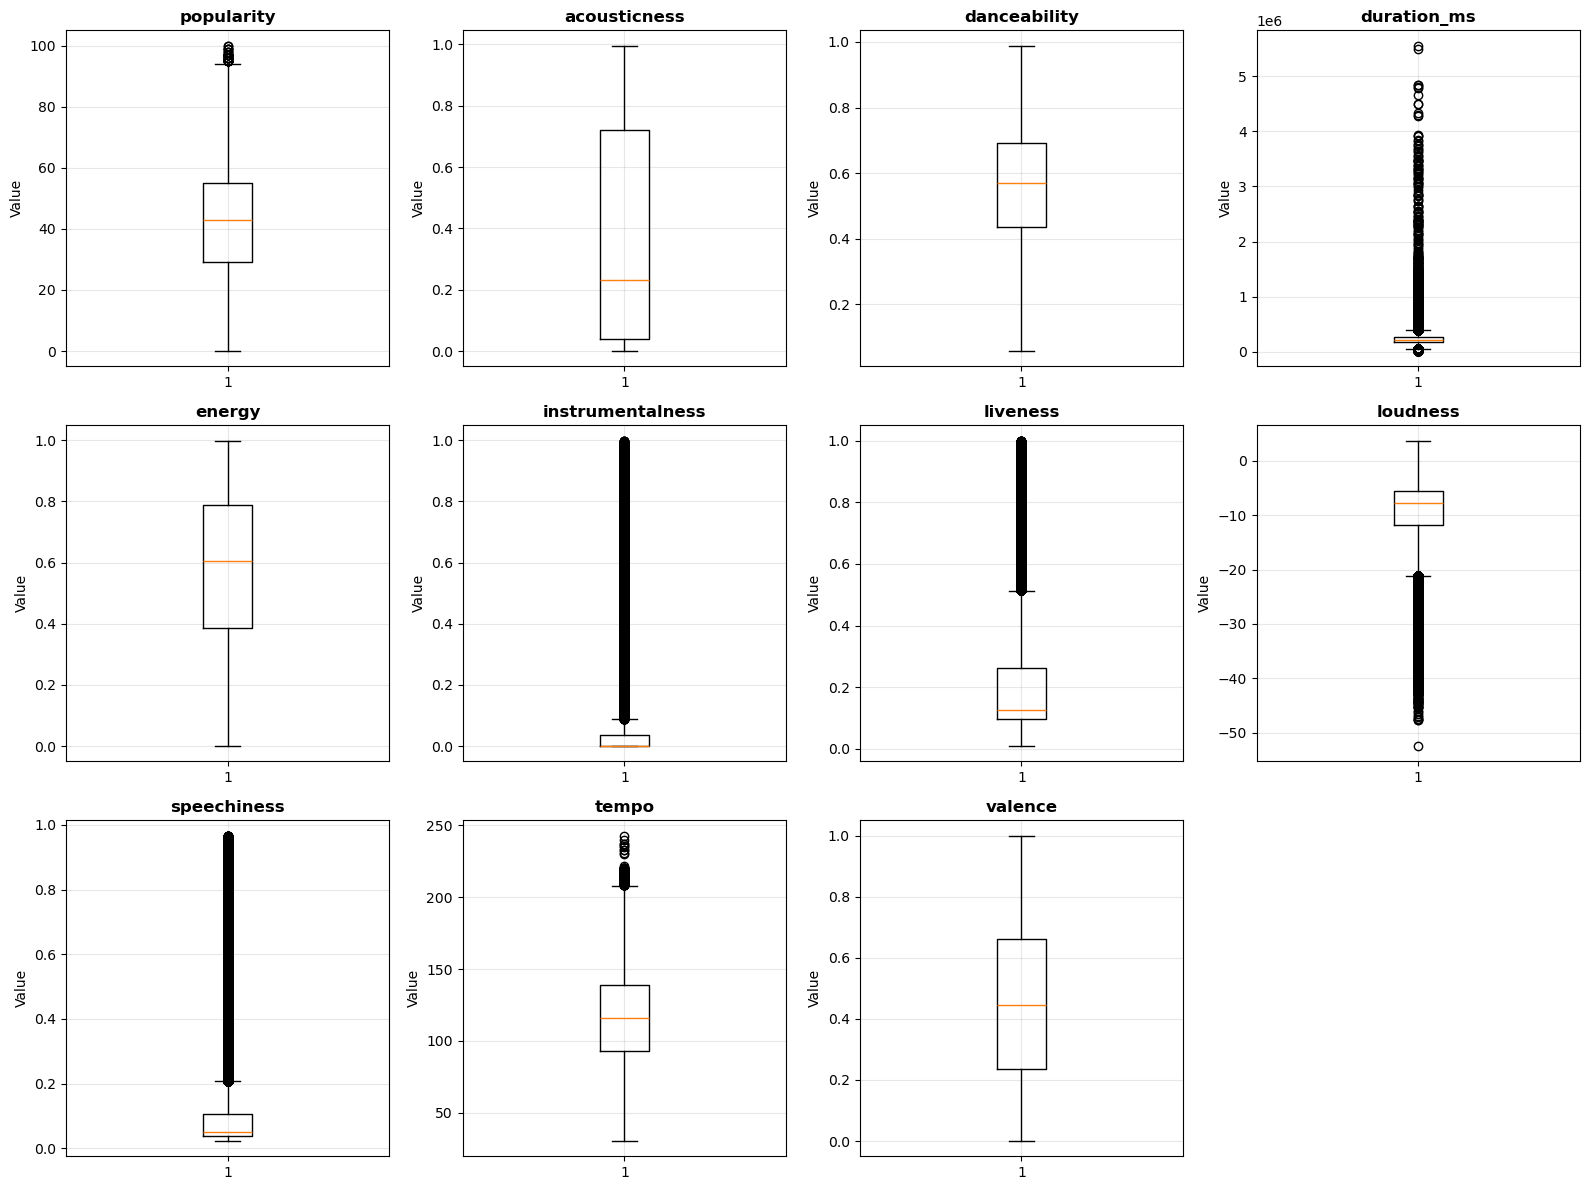

In [7]:
# Calculate the number of rows and columns for the grid
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

# Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()  # Flatten to iterate more easily

# Create a box plot for each numeric variable
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

OUTLIER ANALYSIS - IQR METHOD

popularity:
  Q1: 29.0000, Q3: 55.0000, IQR: 26.0000
  Lower Bound: -10.0000, Upper Bound: 94.0000
  Outliers: 38 (0.02%)
  Data range: [0.0000, 100.0000]

acousticness:
  Q1: 0.0376, Q3: 0.7220, IQR: 0.6844
  Lower Bound: -0.9890, Upper Bound: 1.7486
  Outliers: 0 (0.00%)
  Data range: [0.0000, 0.9960]

danceability:
  Q1: 0.4350, Q3: 0.6920, IQR: 0.2570
  Lower Bound: 0.0495, Upper Bound: 1.0775
  Outliers: 0 (0.00%)
  Data range: [0.0569, 0.9890]

duration_ms:
  Q1: 182857.0000, Q3: 265768.0000, IQR: 82911.0000
  Lower Bound: 58490.5000, Upper Bound: 390134.5000
  Outliers: 14651 (6.30%)
  Data range: [15387.0000, 5552917.0000]

energy:
  Q1: 0.3850, Q3: 0.7870, IQR: 0.4020
  Lower Bound: -0.2180, Upper Bound: 1.3900
  Outliers: 0 (0.00%)
  Data range: [0.0000, 0.9990]

instrumentalness:
  Q1: 0.0000, Q3: 0.0358, IQR: 0.0358
  Lower Bound: -0.0537, Upper Bound: 0.0895
  Outliers: 51545 (22.15%)
  Data range: [0.0000, 0.9990]

liveness:
  Q1: 0.0974, Q3

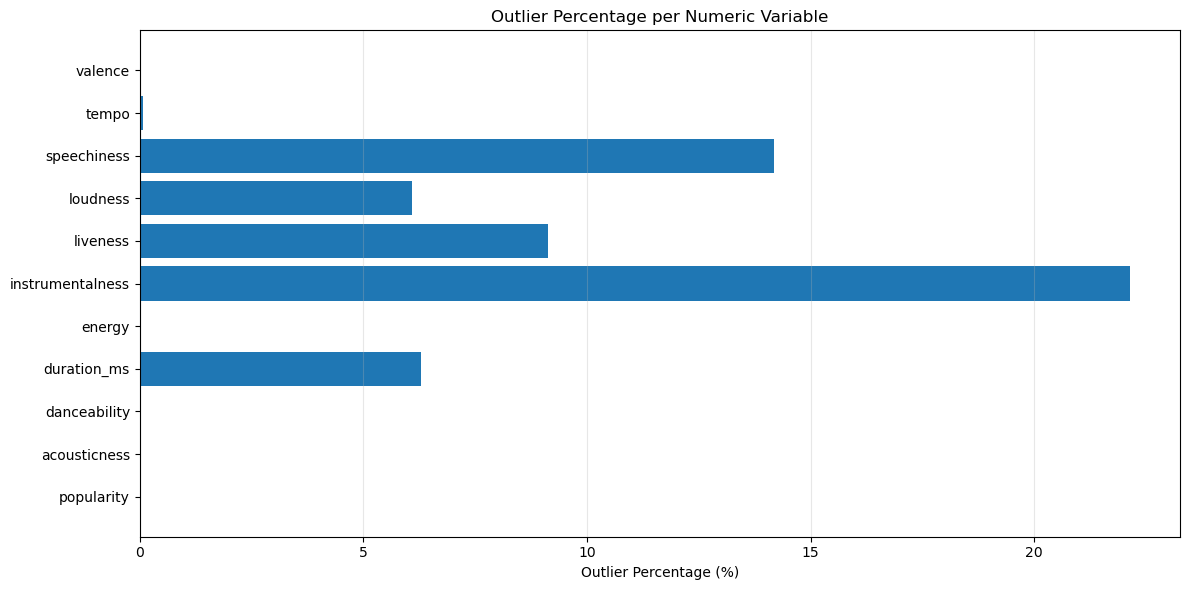

In [8]:
# OUTLIER ANALYSIS - IQR Method (Interquartile Range)
print("OUTLIER ANALYSIS - IQR METHOD")
print("="*80)

outlier_summary = []

for col in numeric_cols:
    # Calculate quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    # Save results
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'N Outlier': n_outliers,
        'Pct Outlier': pct_outliers,
        'Min Value': df[col].min(),
        'Max Value': df[col].max()
    })
    
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
    print(f"  Lower Bound: {lower_bound:.4f}, Upper Bound: {upper_bound:.4f}")
    print(f"  Outliers: {n_outliers} ({pct_outliers:.2f}%)")
    print(f"  Data range: [{df[col].min():.4f}, {df[col].max():.4f}]")

# Create DataFrame with summary
outlier_df = pd.DataFrame(outlier_summary)
print("\n\nOUTLIER SUMMARY:")
print("="*80)
print(outlier_df.to_string(index=False))

# Show variables with most outliers
print("\n\nVARIABLES WITH MOST OUTLIERS:")
print("="*80)
outlier_df_sorted = outlier_df.sort_values('N Outlier', ascending=False)
print(outlier_df_sorted[['Variable', 'N Outlier', 'Pct Outlier']].to_string(index=False))

# Visualize with chart
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(outlier_df['Variable'], outlier_df['Pct Outlier'])
ax.set_xlabel('Outlier Percentage (%)')
ax.set_title('Outlier Percentage per Numeric Variable')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

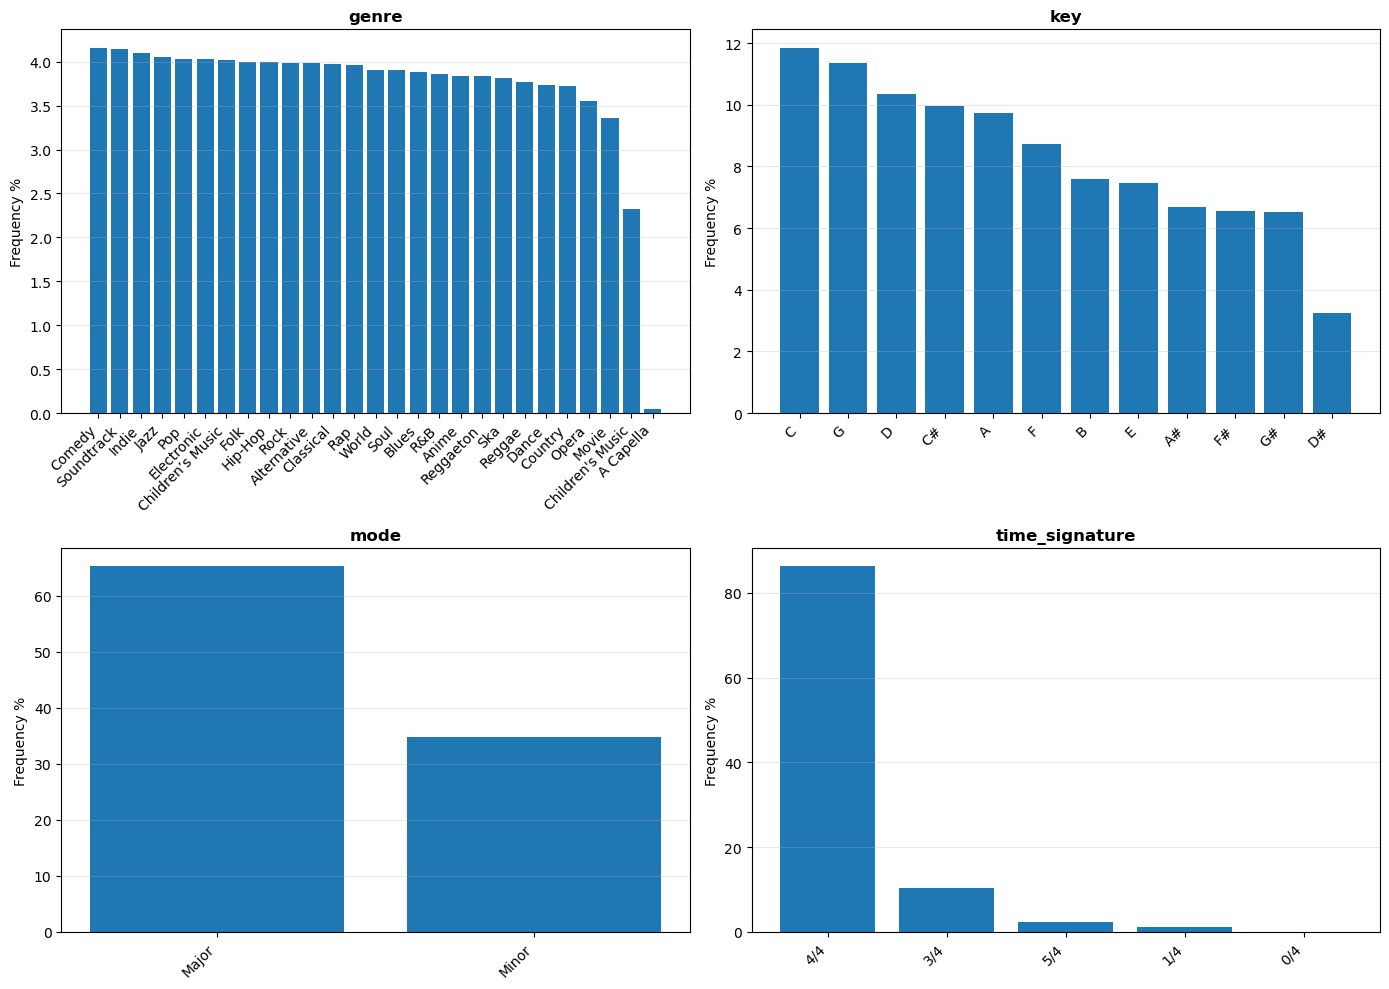

In [9]:
# Calculate the number of rows and columns for the grid
n_cols = 2
n_rows = int(np.ceil(len(object_cols) / n_cols))

# Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()  # Flatten to iterate more easily

# Create a bar plot for each object variable
for idx, col in enumerate(object_cols):
    # Calculate percentage frequencies
    freq_pct = (df[col].value_counts(normalize=True) * 100).sort_values(ascending=False)
    
    # Create the bar plot
    axes[idx].bar(range(len(freq_pct)), freq_pct.values)
    axes[idx].set_xticks(range(len(freq_pct)))
    axes[idx].set_xticklabels(freq_pct.index, rotation=45, ha='right')
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Frequency %')
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide empty subplots
for idx in range(len(object_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_19368\2712850281.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\angel\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


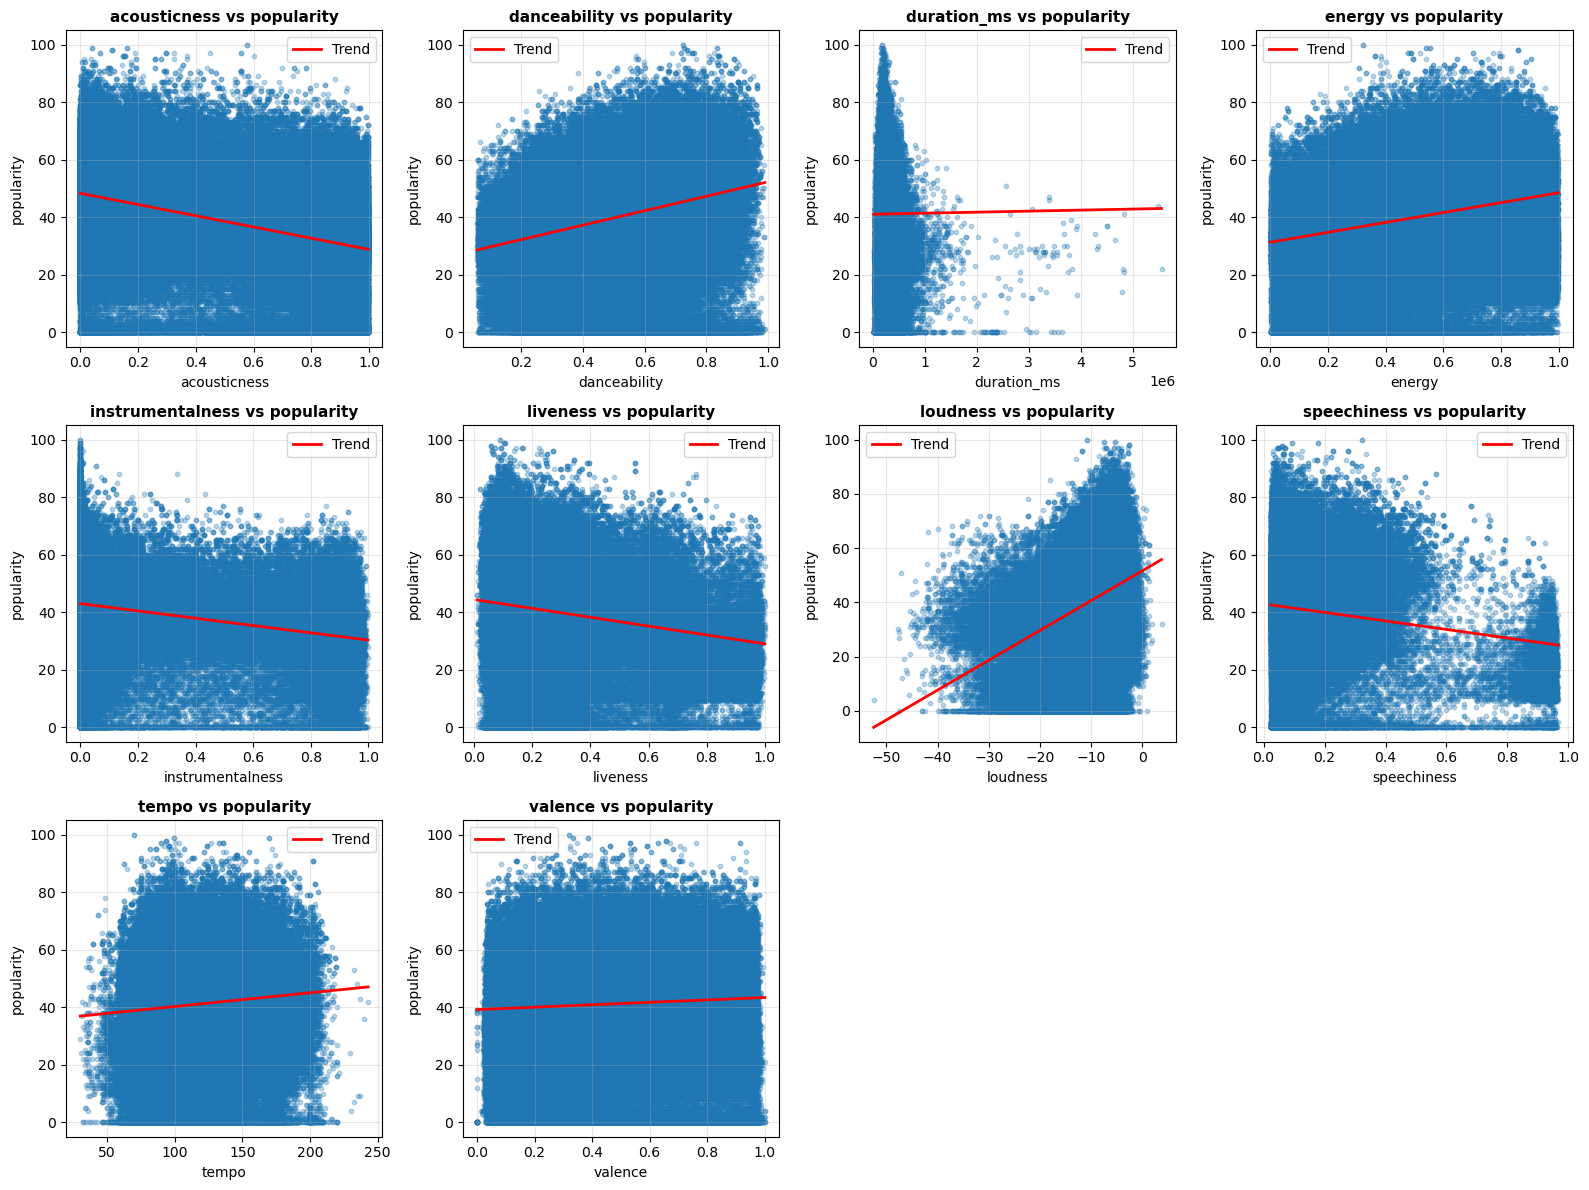

In [10]:
# Exclude popularity from X axis
numeric_vars_vs_pop = [col for col in numeric_cols if col != 'popularity']

# Calculate the number of rows and columns for the grid
n_cols = 4
n_rows = int(np.ceil(len(numeric_vars_vs_pop) / n_cols))

# Create the figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

# Create a scatterplot for each numeric variable vs popularity
for idx, col in enumerate(numeric_vars_vs_pop):
    # Scatterplot
    axes[idx].scatter(df[col], df['popularity'], alpha=0.3, s=10)
    
    # Trend line
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, label='Trend')
    
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('popularity', fontsize=10)
    axes[idx].set_title(f'{col} vs popularity', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

# Hide empty subplots
for idx in range(len(numeric_vars_vs_pop), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

VIOLIN PLOT: Distribution of popularity per category


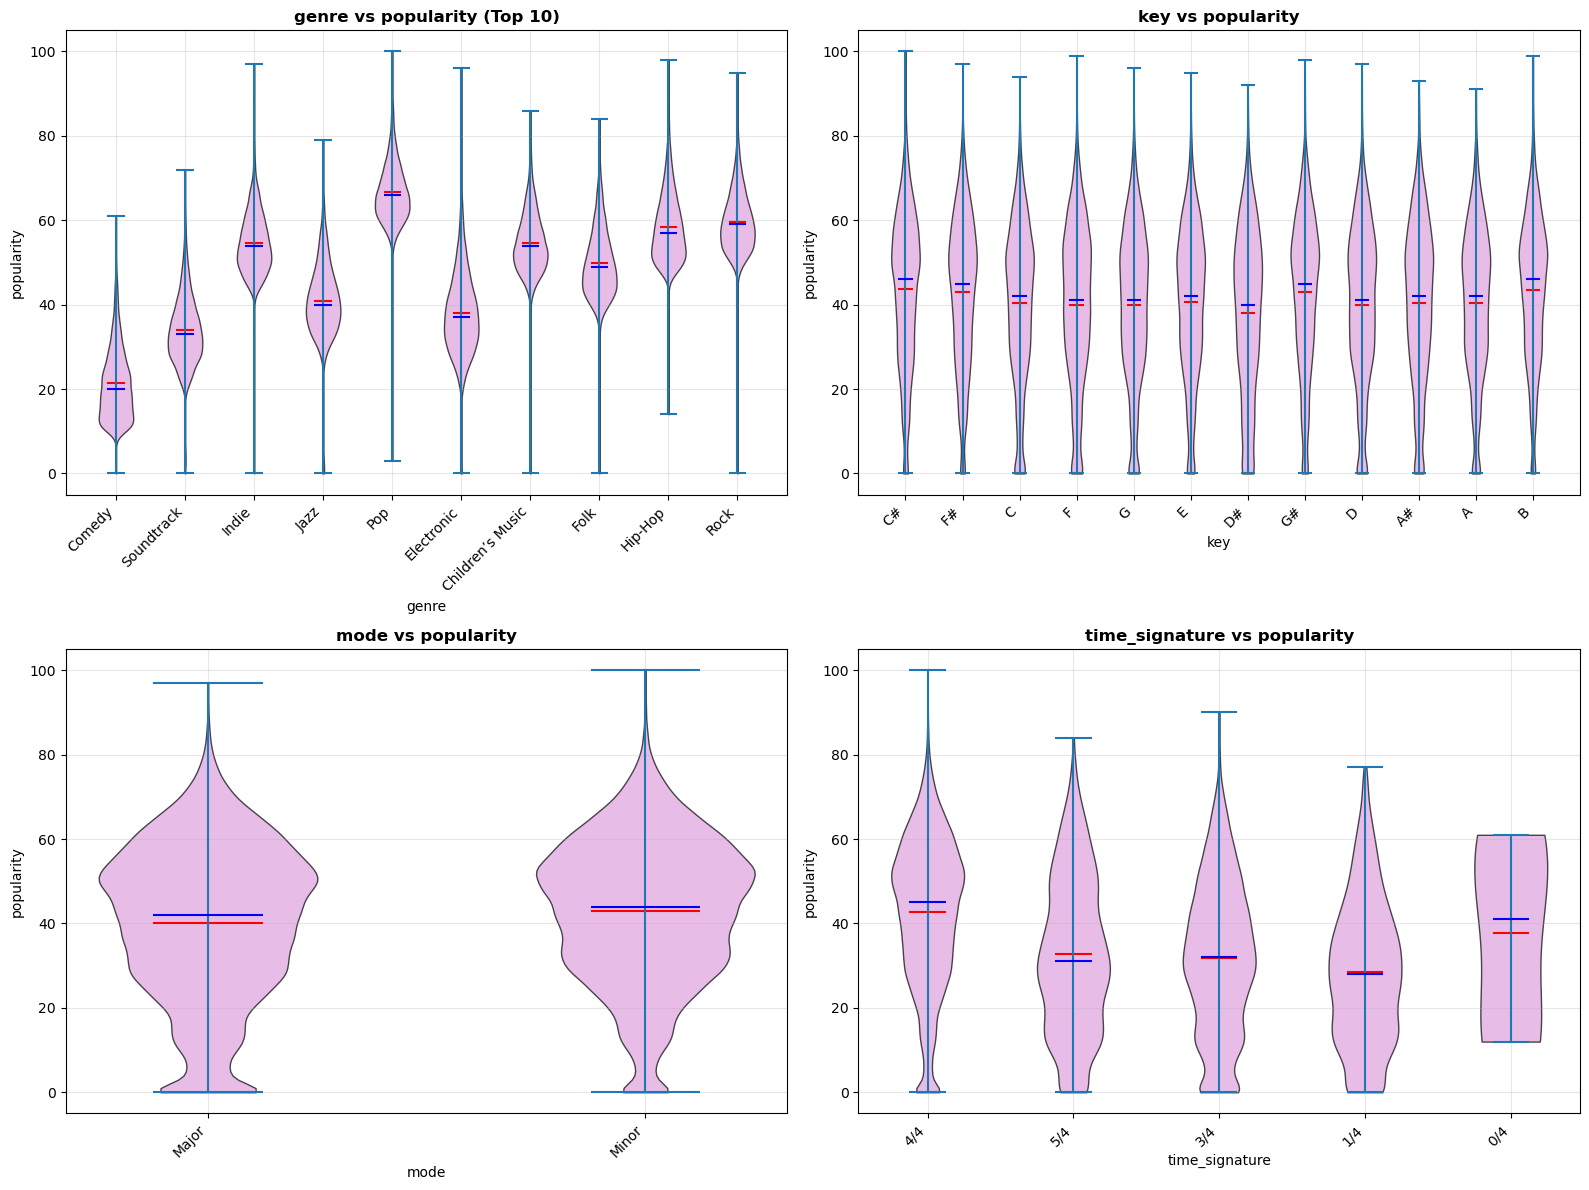

In [11]:
# VIOLIN PLOT: Distribution of popularity for each object variable
print("VIOLIN PLOT: Distribution of popularity per category")
print("="*60)

# Calculate the number of rows and columns for the grid
n_cols = 2
n_rows = int(np.ceil(len(object_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(object_cols):
    # For genre, show only top 10 for readability
    if col == 'genre':
        top_genres = df['genre'].value_counts().head(10).index
        data_to_plot = [df[df['genre'] == genre]['popularity'].dropna() for genre in top_genres]
        labels = top_genres
        title = f'{col} vs popularity (Top 10)'
    else:
        data_to_plot = [df[df[col] == cat]['popularity'].dropna() for cat in df[col].unique()]
        labels = df[col].unique()
        title = f'{col} vs popularity'
    
    # Violin plot
    parts = axes[idx].violinplot(data_to_plot, showmeans=True, showmedians=True)
    
    # Customize colors
    for pc in parts['bodies']:
        pc.set_facecolor('#DDA0DD')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    
    # Mean and median lines
    parts['cmeans'].set_color('red')
    parts['cmedians'].set_color('blue')
    
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('popularity')
    axes[idx].set_xlabel(col)
    axes[idx].set_xticks(range(1, len(labels) + 1))
    axes[idx].set_xticklabels(labels, rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(len(object_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

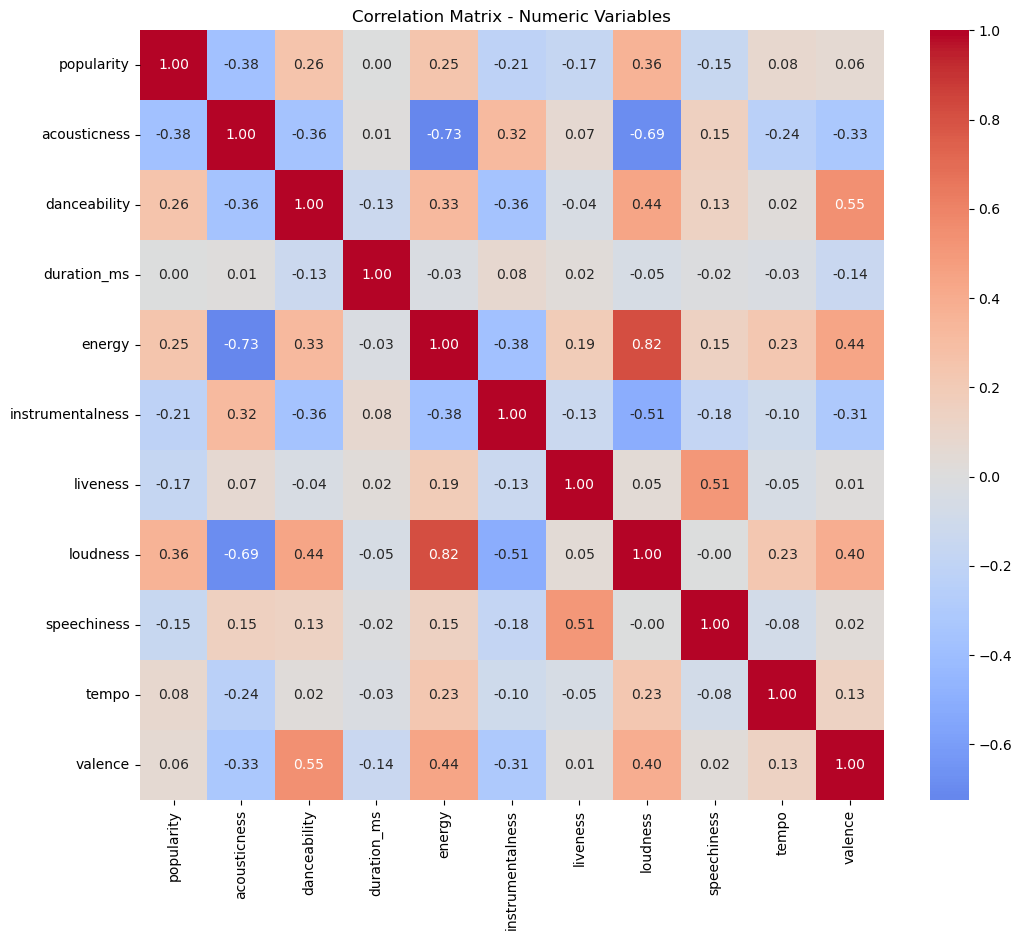

Correlations with popularity:
popularity          1.000000
loudness            0.363011
danceability        0.256564
energy              0.248922
tempo               0.081039
valence             0.060076
duration_ms         0.002348
speechiness        -0.151076
liveness           -0.167995
instrumentalness   -0.210983
acousticness       -0.381295
Name: popularity, dtype: float64


In [12]:
# Calculate correlations
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Numeric Variables')
plt.show()

# Correlations with popularity (sorted)
pop_corr = corr_matrix['popularity'].sort_values(ascending=False)
print("Correlations with popularity:")
print(pop_corr)

ASSOCIATION BETWEEN POPULARITY AND CATEGORICAL VARIABLES:
genre (top 10): F=26571.81, p=0.0000, eta²=0.717
key: F=153.96, p=0.0000, eta²=0.007
mode: F=1164.13, p=0.0000, eta²=0.005
time_signature: F=2624.37, p=0.0000, eta²=0.043


CRAMÉR'S V MATRIX BETWEEN CATEGORICAL VARIABLES:
                   genre       key      mode time_signature
genre                1.0  0.078105  0.177198       0.216198
key             0.078105       1.0  0.240976       0.026295
mode            0.177198  0.240976       1.0       0.025498
time_signature  0.216198  0.026295  0.025498            1.0


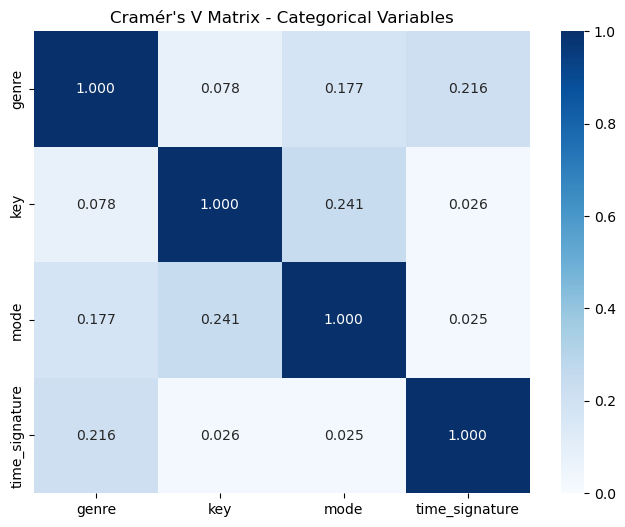

In [13]:
from scipy.stats import chi2_contingency, f_oneway
import numpy as np

# Function for Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Function for eta-squared (for ANOVA)
def eta_squared(groups):
    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)
    ss_total = np.sum((all_values - grand_mean)**2)
    ss_between = sum(len(group) * (np.mean(group) - grand_mean)**2 for group in groups)
    return ss_between / ss_total if ss_total > 0 else 0

print("ASSOCIATION BETWEEN POPULARITY AND CATEGORICAL VARIABLES:")
print("="*60)

for col in object_cols:
    # ANOVA
    if col == 'genre':
        # For genre, use only top 10 for efficiency
        top_genres = df['genre'].value_counts().head(10).index
        groups = [df[df['genre'] == g]['popularity'].dropna() for g in top_genres]
        f_stat, p_value = f_oneway(*groups)
        eta2 = eta_squared(groups)
        print(f"{col} (top 10): F={f_stat:.2f}, p={p_value:.4f}, eta²={eta2:.3f}")
    else:
        groups = [df[df[col] == cat]['popularity'].dropna() for cat in df[col].unique()]
        f_stat, p_value = f_oneway(*groups)
        eta2 = eta_squared(groups)
        print(f"{col}: F={f_stat:.2f}, p={p_value:.4f}, eta²={eta2:.3f}")

print("\n\nCRAMÉR'S V MATRIX BETWEEN CATEGORICAL VARIABLES:")
print("="*60)

# Create matrix
cramers_matrix = pd.DataFrame(index=object_cols, columns=object_cols)

for i, col1 in enumerate(object_cols):
    for j, col2 in enumerate(object_cols):
        if i == j:
            cramers_matrix.loc[col1, col2] = 1.0  # Diagonal
        elif i < j:
            if col1 == 'genre' or col2 == 'genre':
                # For genre, limit to top 10
                if col1 == 'genre':
                    data1 = df[df['genre'].isin(df['genre'].value_counts().head(10).index)]['genre']
                    data2 = df.loc[data1.index, col2]
                else:
                    data2 = df[df['genre'].isin(df['genre'].value_counts().head(10).index)]['genre']
                    data1 = df.loc[data2.index, col1]
                v = cramers_v(data1, data2)
            else:
                v = cramers_v(df[col1], df[col2])
            cramers_matrix.loc[col1, col2] = v
            cramers_matrix.loc[col2, col1] = v
        else:
            continue

print(cramers_matrix.round(3))

# Heatmap for Cramér's V
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap='Blues', vmin=0, vmax=1, fmt='.3f')
plt.title("Cramér's V Matrix - Categorical Variables")
plt.show()

# DATA PREPARATION

In [ ]:
# Create a copy of the dataset
df_copy = df[numeric_cols + object_cols].copy()

# One-hot encoding of categorical variables
# Note: we exclude the already excluded columns (artist_name, track_name, track_id)
categorical_cols = ['genre', 'key', 'mode', 'time_signature']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_copy, columns=categorical_cols, drop_first=False)

print("Original dataset shape:", df_copy.shape)
print("Dataset after one-hot encoding shape:", df_encoded.shape)
print("\nNew columns added:")
encoded_cols = [col for col in df_encoded.columns if col not in df_copy.columns]
print(encoded_cols)

# Split the dataset into 80% training and 20% test with shuffling
train_df, test_df = train_test_split(df_encoded, test_size=0.2, random_state=42, shuffle=True)

print(f"\nTraining set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Original dataset shape: (232725, 15)
Dataset after one-hot encoding shape: (232725, 57)

New columns added:
['genre_A Capella', 'genre_Alternative', 'genre_Anime', 'genre_Blues', "genre_Children's Music", 'genre_Children’s Music', 'genre_Classical', 'genre_Comedy', 'genre_Country', 'genre_Dance', 'genre_Electronic', 'genre_Folk', 'genre_Hip-Hop', 'genre_Indie', 'genre_Jazz', 'genre_Movie', 'genre_Opera', 'genre_Pop', 'genre_R&B', 'genre_Rap', 'genre_Reggae', 'genre_Reggaeton', 'genre_Rock', 'genre_Ska', 'genre_Soul', 'genre_Soundtrack', 'genre_World', 'key_A', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'mode_Major', 'mode_Minor', 'time_signature_0/4', 'time_signature_1/4', 'time_signature_3/4', 'time_signature_4/4', 'time_signature_5/4']

Training set shape: (186180, 57)
Test set shape: (46545, 57)


In [ ]:
# DATA PREPARATION
# Separate features and target
X_train = train_df.drop('popularity', axis=1)
y_train = train_df['popularity']
from sklearn.model_selection import RandomizedSearchCV

# DATA PREPARATION
# Separate features and target
X_train = train_df.drop('popularity', axis=1)
y_train = train_df['popularity']

X_test = test_df.drop('popularity', axis=1)
y_test = test_df['popularity']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (186180, 56)
X_test shape: (46545, 56)


In [ ]:
# Create a copy of the dataset with selected columns
df_lr_copy = df[numeric_cols + object_cols].copy()

# One-hot encoding of categorical variables
df_lr_encoded = pd.get_dummies(df_lr_copy, columns=object_cols, drop_first=False)

# Split into train/test with the same random_state used before
train_lr_df, test_lr_df = train_test_split(
    df_lr_encoded,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Separate features and target
X_train_lr = train_lr_df.drop('popularity', axis=1).copy()
X_test_lr = test_lr_df.drop('popularity', axis=1).copy()
y_train_lr = train_lr_df['popularity']
y_test_lr = test_lr_df['popularity']

# Remove loudness from numeric features
if 'loudness' in X_train_lr.columns:
    X_train_lr = X_train_lr.drop(columns=['loudness'])
    X_test_lr = X_test_lr.drop(columns=['loudness'])

# Scaling of remaining numeric features
numeric_features_lr = [col for col in numeric_cols if col not in ('popularity', 'loudness')]

scaler_lr = StandardScaler()
X_train_lr[numeric_features_lr] = scaler_lr.fit_transform(X_train_lr[numeric_features_lr])
X_test_lr[numeric_features_lr] = scaler_lr.transform(X_test_lr[numeric_features_lr])

# MODELING

In [24]:
# DEFINE HYPERPARAMETER DISTRIBUTION FOR RANDOMIZEDSEARCHCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', 0.5, 0.7, 0.9]
}

# HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV
print("\nSTARTING RANDOMIZEDSEARCHCV - Much faster than GridSearch...")
print("="*80)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# RandomizedSearchCV with 20 iterations and 3-fold cross-validation
random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=20,  # number of random combinations to try
    cv=3,  # 3-fold cross-validation (faster)
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\nBest hyperparameters found:")
print(random_search.best_params_)
print(f"Best CV score: {-random_search.best_score_:.4f} (negative MSE)")

# TRAIN MODEL WITH BEST PARAMETERS
best_rf = random_search.best_estimator_


STARTING RANDOMIZEDSEARCHCV - Much faster than GridSearch...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best hyperparameters found:
{'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.5, 'max_depth': None}
Best CV score: 86.2347 (negative MSE)


In [21]:
best_rf=RandomForestRegressor(
    n_estimators=250,
    min_samples_split=2,
    min_samples_leaf=8,
    max_features=0.5,
    max_depth=None)

best_rf.fit(X_train, y_train)

,n_estimators,250
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,0.5
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predictions
y_train_lr_pred = lr_model.predict(X_train_lr)
y_test_lr_pred = lr_model.predict(X_test_lr)

# MODEL EVALUATION



MODEL RESULTS (with Integer Predictions 1-100):
Training RMSE: 7.1127, Test RMSE: 9.2598
Training MAE:  5.2594, Test MAE:  7.0141
Training R²:   0.8469, Test R²:   0.7425

Test/Train RMSE Ratio (Overfitting Index): 1.3019
⚠️  WARNING: Possible overfitting (ratio > 1.1)


PREDICTION EXAMPLES (Test Set):
 Actual_Value  Prediction  Error
           45          44      1
           25          33      8
           19          35     16
           29          39     10
           17          24      7
           16           6     10
           63          66      3
           51          61     10
           41          48      7
           65          47     18


TOP 15 MOST IMPORTANT FEATURES:
               Feature  Importance
          acousticness    0.110966
genre_Children's Music    0.107719
           genre_Movie    0.091459
              loudness    0.072788
             genre_Pop    0.062804
           genre_Anime    0.054974
           genre_Opera    0.045472
             genr

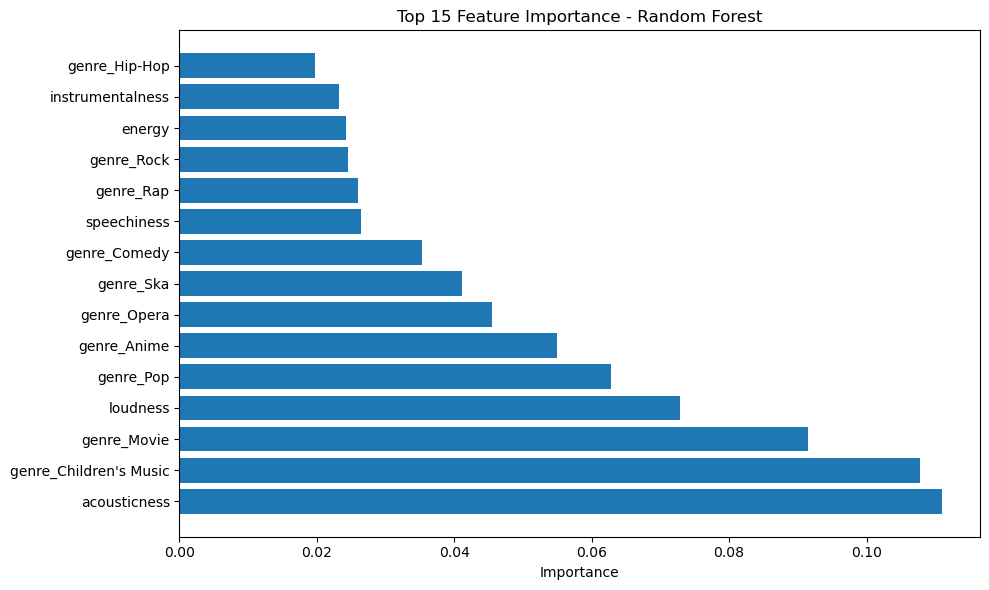

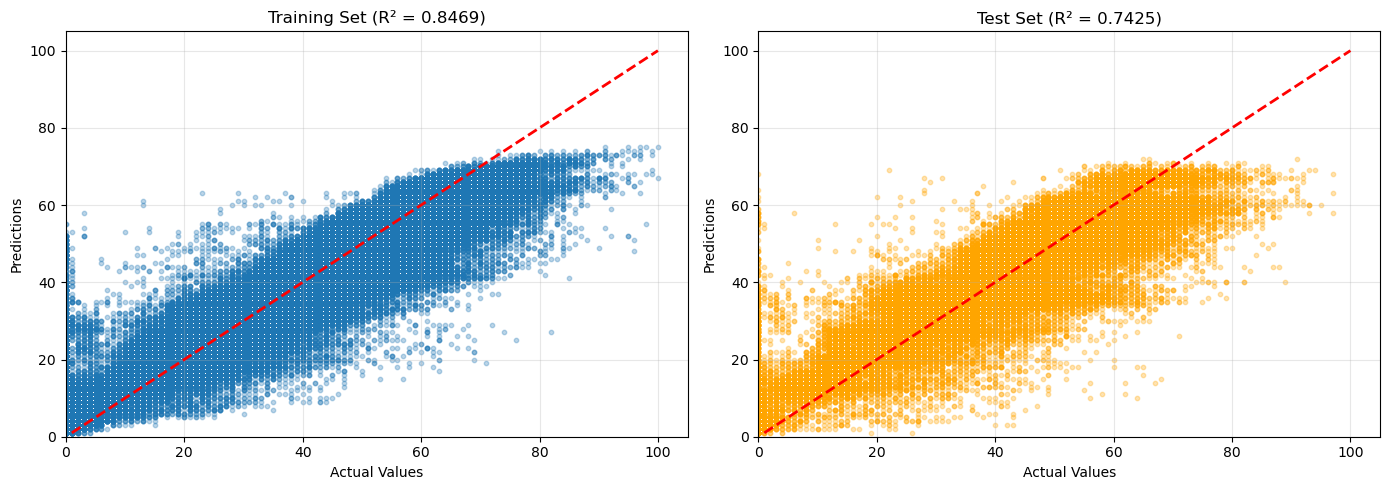

In [22]:
# EVALUATE ON TRAINING AND TEST SET
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# ROUND TO INTEGERS AND CLIP BETWEEN 1-100
y_train_pred = np.clip(np.round(y_train_pred), 1, 100).astype(int)
y_test_pred = np.clip(np.round(y_test_pred), 1, 100).astype(int)

# Metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n\nMODEL RESULTS (with Integer Predictions 1-100):")
print("="*80)
print(f"Training RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
print(f"Training MAE:  {train_mae:.4f}, Test MAE:  {test_mae:.4f}")
print(f"Training R²:   {train_r2:.4f}, Test R²:   {test_r2:.4f}")

# Check overfitting
overfitting_ratio = test_rmse / train_rmse
print(f"\nTest/Train RMSE Ratio (Overfitting Index): {overfitting_ratio:.4f}")
if overfitting_ratio > 1.1:
    print("⚠️  WARNING: Possible overfitting (ratio > 1.1)")
else:
    print("✓ Well-balanced model (no significant overfitting)")

# Show some prediction examples
print("\n\nPREDICTION EXAMPLES (Test Set):")
print("="*80)
examples_df = pd.DataFrame({
    'Actual_Value': y_test.values[:10],
    'Prediction': y_test_pred[:10],
    'Error': np.abs(y_test.values[:10] - y_test_pred[:10])
})
print(examples_df.to_string(index=False))

# FEATURE IMPORTANCE
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n\nTOP 15 MOST IMPORTANT FEATURES:")
print("="*80)
print(feature_importance.head(15).to_string(index=False))

# Visualize feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'].head(15), feature_importance['Importance'].head(15))
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# VISUALIZE PREDICTIONS vs ACTUAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([1, 100], [1, 100], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predictions')
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})')
axes[0].set_xlim(0, 105)
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
axes[1].plot([1, 100], [1, 100], 'r--', lw=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predictions')
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})')
axes[1].set_xlim(0, 105)
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Metrics
train_lr_mse = mean_squared_error(y_train_lr, y_train_lr_pred)
test_lr_mse = mean_squared_error(y_test_lr, y_test_lr_pred)
train_lr_rmse = np.sqrt(train_lr_mse)
test_lr_rmse = np.sqrt(test_lr_mse)
train_lr_mae = mean_absolute_error(y_train_lr, y_train_lr_pred)
test_lr_mae = mean_absolute_error(y_test_lr, y_test_lr_pred)
train_lr_r2 = r2_score(y_train_lr, y_train_lr_pred)
test_lr_r2 = r2_score(y_test_lr, y_test_lr_pred)

print("LINEAR REGRESSION RESULTS")
print("="*60)
print(f"Train RMSE: {train_lr_rmse:.4f}, Test RMSE: {test_lr_rmse:.4f}")
print(f"Train MAE:  {train_lr_mae:.4f}, Test MAE:  {test_lr_mae:.4f}")
print(f"Train R²:   {train_lr_r2:.4f}, Test R²:   {test_lr_r2:.4f}")

LINEAR REGRESSION RESULTS
Train RMSE: 9.5873, Test RMSE: 9.6073
Train MAE:  7.2475, Test MAE:  7.2684
Train R²:   0.7218, Test R²:   0.7228
